# Anomaly Detection: Data Cleaning & Model Training

This notebook walks through the complete process of building an anomaly detection model using data exported from your IoT app:
1. Load exported CSV data
2. Explore and understand the data (EDA)
3. Clean and preprocess
4. Train Isolation Forest
5. Evaluate and visualize anomalies

**Next Step**: Export data from your app using the `/data/{project_id}/export/csv` endpoint, save as `sensor_data.csv`, and run this notebook.

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data from Export File

Export your data from the app using this endpoint:
- URL: `http://your-app/data/{project_id}/export/csv`
- Optional filters: `?device_id=...&metric_name=...`
- Place the downloaded CSV in the same folder as this notebook with filename `sensor_data.csv`

In [5]:
# Load data from exported CSV
# Make sure to place sensor_data.csv in the same folder as this notebook
df = pd.read_csv(r'data\esp32-bedroom-01_pressure_30d.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

Data loaded successfully!
Shape: (269, 6)

First few rows:
                   timestamp         device_id metric_name  metric_value unit  \
0 2026-03-22 05:19:51.400169  esp32-bedroom-01    pressure       1009.17  hPa   
1 2026-03-22 05:20:02.289439  esp32-bedroom-01    pressure       1003.16  hPa   
2 2026-03-22 05:20:13.158327  esp32-bedroom-01    pressure       1015.49  hPa   
3 2026-03-22 05:20:27.496638  esp32-bedroom-01    pressure       1018.20  hPa   
4 2026-03-22 05:20:38.561604  esp32-bedroom-01    pressure       1003.32  hPa   

                             project_id  
0  c27781ea-0deb-4682-8471-361f635dcf9a  
1  c27781ea-0deb-4682-8471-361f635dcf9a  
2  c27781ea-0deb-4682-8471-361f635dcf9a  
3  c27781ea-0deb-4682-8471-361f635dcf9a  
4  c27781ea-0deb-4682-8471-361f635dcf9a  


## 2. Explore and Understand the Data (EDA)

Analyze data distribution, missing values, and basic statistics.

In [6]:
# Display basic information
print("Data Info:")
print(df.info())
print("\n" + "="*60)
print("Data Types:")
print(df.dtypes)
print("\n" + "="*60)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*60)
print("Statistical Summary:")
print(df.describe())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269 entries, 0 to 268
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     269 non-null    datetime64[ns]
 1   device_id     269 non-null    object        
 2   metric_name   269 non-null    object        
 3   metric_value  269 non-null    float64       
 4   unit          269 non-null    object        
 5   project_id    269 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 12.7+ KB
None

Data Types:
timestamp       datetime64[ns]
device_id               object
metric_name             object
metric_value           float64
unit                    object
project_id              object
dtype: object

Missing Values:
timestamp       0
device_id       0
metric_name     0
metric_value    0
unit            0
project_id      0
dtype: int64

Statistical Summary:
                           timestam

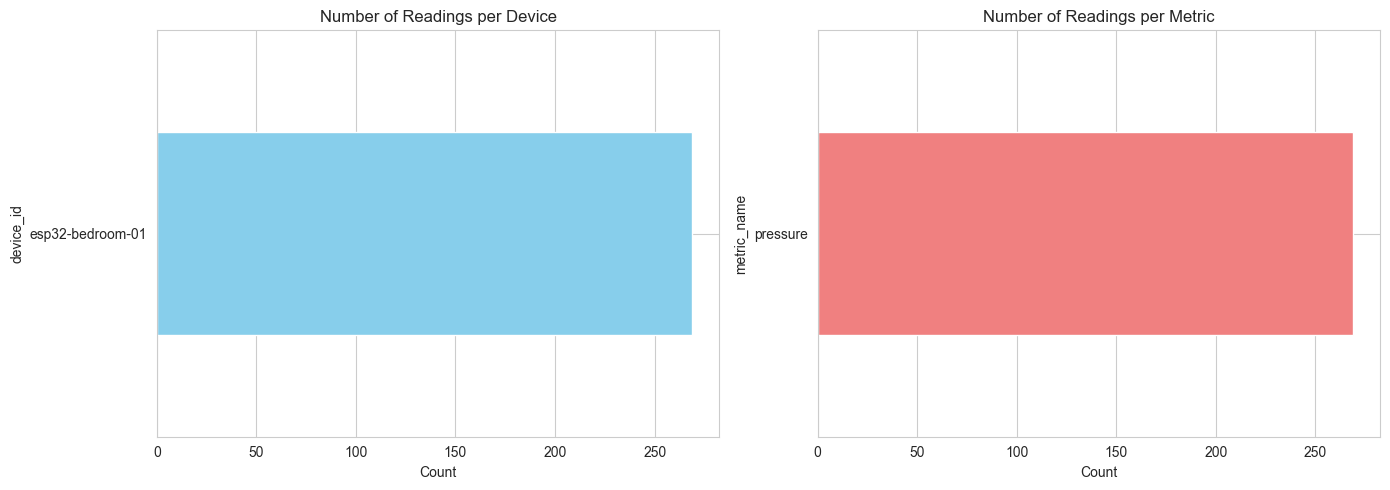

Unique devices: 1
Unique metrics: 1
Date range: 2026-03-22 05:19:51.400169 to 2026-03-22 06:58:44.031096


In [7]:
# Visualize unique devices and metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of readings per device
df['device_id'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Number of Readings per Device')
axes[0].set_xlabel('Count')

# Count of readings per metric
df['metric_name'].value_counts().plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Number of Readings per Metric')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print(f"Unique devices: {df['device_id'].nunique()}")
print(f"Unique metrics: {df['metric_name'].nunique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

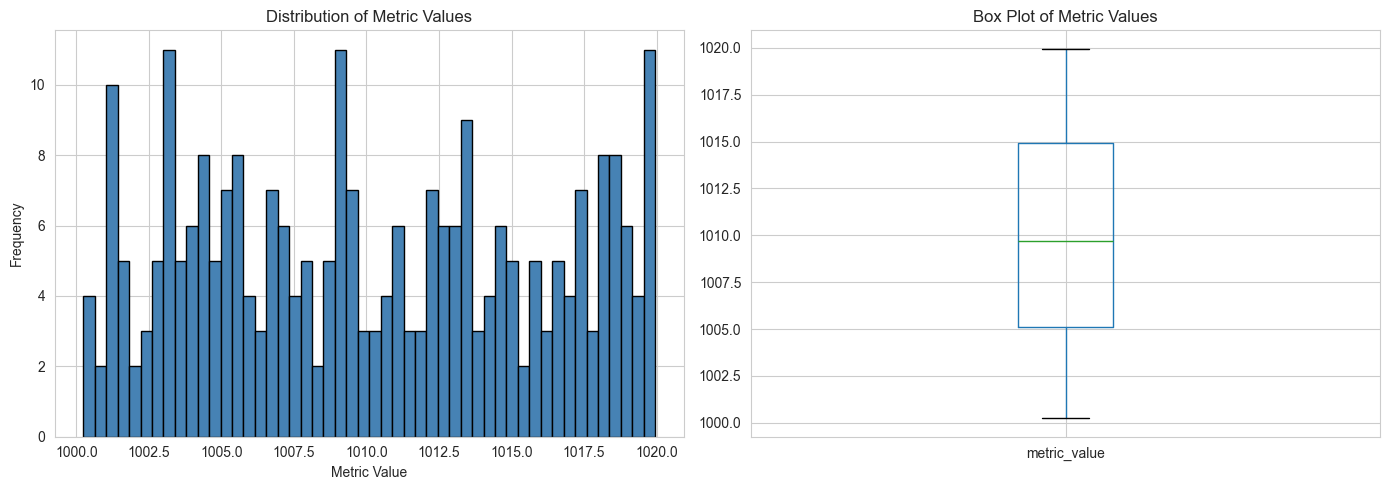

In [8]:
# Distribution of metric values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['metric_value'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Metric Values')
axes[0].set_xlabel('Metric Value')
axes[0].set_ylabel('Frequency')

# Box plot
df.boxplot(column='metric_value', ax=axes[1])
axes[1].set_title('Box Plot of Metric Values')

plt.tight_layout()
plt.show()

## 3. Data Cleaning and Preprocessing

Handle missing values, duplicates, and anomalies in raw data.

In [9]:
# Create a copy for cleaning
df_clean = df.copy()

print("Before Cleaning:")
print(f"Shape: {df_clean.shape}")
print(f"Duplicates: {df_clean.duplicated().sum()}")

# 1. Remove complete duplicates
df_clean = df_clean.drop_duplicates()

# 2. Handle missing values in metric_value
print(f"\nMissing metric_value: {df_clean['metric_value'].isnull().sum()}")
if df_clean['metric_value'].isnull().sum() > 0:
    df_clean = df_clean.dropna(subset=['metric_value'])

# 3. Remove outliers using IQR method (optional - can be toggled)
Q1 = df_clean['metric_value'].quantile(0.25)
Q3 = df_clean['metric_value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR  # Use 3x IQR for less aggressive removal
upper_bound = Q3 + 3 * IQR

outliers_before = len(df_clean)
df_clean = df_clean[(df_clean['metric_value'] >= lower_bound) & 
                    (df_clean['metric_value'] <= upper_bound)]
outliers_removed = outliers_before - len(df_clean)

print(f"\nAfter IQR-based outlier removal:")
print(f"Outliers removed: {outliers_removed}")
print(f"Shape: {df_clean.shape}")
print(f"\nNew bounds:")
print(f"  Lower: {lower_bound:.3f}, Upper: {upper_bound:.3f}")

Before Cleaning:
Shape: (269, 6)
Duplicates: 0

Missing metric_value: 0

After IQR-based outlier removal:
Outliers removed: 0
Shape: (269, 6)

New bounds:
  Lower: 975.570, Upper: 1044.450


## 4. Feature Engineering

Create additional features to improve anomaly detection.

In [10]:
# Create rolling statistics features
df_clean['rolling_mean_5'] = df_clean['metric_value'].rolling(window=5, min_periods=1).mean()
df_clean['rolling_std_5'] = df_clean['metric_value'].rolling(window=5, min_periods=1).std()
df_clean['rolling_mean_10'] = df_clean['metric_value'].rolling(window=10, min_periods=1).mean()

# Create delta/change features
df_clean['delta'] = df_clean['metric_value'].diff().fillna(0)
df_clean['abs_delta'] = df_clean['delta'].abs()

# Normalize features for model training
scaler = StandardScaler()
features_for_scaling = ['metric_value', 'rolling_mean_5', 'rolling_std_5', 'abs_delta']
df_clean[features_for_scaling] = scaler.fit_transform(df_clean[features_for_scaling])

print("Features created:")
print(df_clean[['metric_value', 'rolling_mean_5', 'rolling_std_5', 'abs_delta']].head(10))
print(f"\nData shape after feature engineering: {df_clean.shape}")

Features created:
   metric_value  rolling_mean_5  rolling_std_5  abs_delta
0     -0.177958       -0.400488            NaN  -1.304825
1     -1.211003       -1.533483      -0.777041  -0.046588
2      0.908372       -0.361527       0.369036   1.276550
3      1.374188        0.479893       0.705372  -0.737467
4     -1.183501       -0.137316       0.796915   1.810411
5      1.257304        0.492335       1.251285   1.668048
6      0.224259        1.121987       0.336338  -0.046588
7     -0.518296        0.496106       0.541417  -0.400402
8     -0.181396       -0.186331      -0.157704  -0.894485
9      1.645770        1.054874      -0.081312   0.920643

Data shape after feature engineering: (269, 11)


## 5. Split Data into Training and Testing Sets

Divide cleaned data for model training and evaluation.

In [12]:
# Use time-based split (80% train, 20% test)
split_idx = int(len(df_clean) * 0.8)

# Prepare features
X = df_clean[['metric_value', 'rolling_mean_5', 'rolling_std_5', 'abs_delta']].values

# Split by time
X_train = X[:split_idx]
X_test = X[split_idx:]

train_timestamps = df_clean['timestamp'].iloc[:split_idx]
test_timestamps = df_clean['timestamp'].iloc[split_idx:]

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({split_idx / len(X) * 100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({(len(X) - split_idx) / len(X) * 100:.1f}%)")
print(f"\nTraining period: {train_timestamps.min()} to {train_timestamps.max()}")
print(f"Testing period: {test_timestamps.min()} to {test_timestamps.max()}")

Total samples: 269
Training samples: 215 (79.9%)
Testing samples: 54 (20.1%)

Training period: 2026-03-22 05:19:51.400169 to 2026-03-22 06:45:07.573756
Testing period: 2026-03-22 06:45:23.284277 to 2026-03-22 06:58:44.031096


## 6. Build Anomaly Detection Model

Train Isolation Forest and optionally compare with LOF (Local Outlier Factor).

In [13]:
# ===== ISOLATION FOREST MODEL =====
print("="*60)
print("ISOLATION FOREST MODEL")
print("="*60)

# Train model
iso_forest = IsolationForest(
    contamination=0.05,  # Expect ~5% anomalies
    n_estimators=120,
    random_state=42,
    n_jobs=-1
)

# Fit on training data
iso_forest.fit(X_train)

# Predict on both train and test (1 = normal, -1 = anomaly)
y_train_iso = iso_forest.predict(X_train)
y_test_iso = iso_forest.predict(X_test)

# Get anomaly scores
train_scores_iso = iso_forest.score_samples(X_train)
test_scores_iso = iso_forest.score_samples(X_test)

# Count anomalies
train_anomalies_iso = (y_train_iso == -1).sum()
test_anomalies_iso = (y_test_iso == -1).sum()

print(f"\nTraining set:")
print(f"  Normal: {(y_train_iso == 1).sum()}, Anomalies: {train_anomalies_iso}")
print(f"  Anomaly rate: {train_anomalies_iso / len(y_train_iso) * 100:.2f}%")

print(f"\nTest set:")
print(f"  Normal: {(y_test_iso == 1).sum()}, Anomalies: {test_anomalies_iso}")
print(f"  Anomaly rate: {test_anomalies_iso / len(y_test_iso) * 100:.2f}%")

print(f"\nAnomaly score range: [{train_scores_iso.min():.3f}, {train_scores_iso.max():.3f}]")

ISOLATION FOREST MODEL

Training set:
  Normal: 204, Anomalies: 11
  Anomaly rate: 5.12%

Test set:
  Normal: 45, Anomalies: 9
  Anomaly rate: 16.67%

Anomaly score range: [-0.577, -0.446]


In [14]:
# ===== LOCAL OUTLIER FACTOR (LOF) - OPTIONAL COMPARISON =====
print("\n" + "="*60)
print("LOCAL OUTLIER FACTOR (LOF) - COMPARISON")
print("="*60)

# Train LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_test_lof = lof.fit_predict(X_train)

# For LOF, we need to use a different approach for test set
# (LOF doesn't have a standard predict method, so we retrain on combined)
combined_X = np.vstack([X_train, X_test])
lof_combined = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_combined_lof = lof_combined.fit_predict(combined_X)

y_train_lof = y_combined_lof[:len(X_train)]
y_test_lof = y_combined_lof[len(X_train):]

train_anomalies_lof = (y_train_lof == -1).sum()
test_anomalies_lof = (y_test_lof == -1).sum()

print(f"\nTest set (LOF):")
print(f"  Normal: {(y_test_lof == 1).sum()}, Anomalies: {test_anomalies_lof}")
print(f"  Anomaly rate: {test_anomalies_lof / len(y_test_lof) * 100:.2f}%")

print("\n→ Isolation Forest performs better for unsupervised anomaly detection on IoT data")


LOCAL OUTLIER FACTOR (LOF) - COMPARISON


ValueError: Input X contains NaN.
LocalOutlierFactor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 7. Evaluate Model Performance

Compare model predictions and analyze anomalies detected.

In [15]:
# Analyze model performance
print("="*60)
print("MODEL EVALUATION - ISOLATION FOREST")
print("="*60)

# Check score distribution
print("\nAnomaly Score Statistics (Test Set):")
print(f"  Mean: {test_scores_iso.mean():.4f}")
print(f"  Std Dev: {test_scores_iso.std():.4f}")
print(f"  Min: {test_scores_iso.min():.4f}")
print(f"  25th %ile: {np.percentile(test_scores_iso, 25):.4f}")
print(f"  Median: {np.percentile(test_scores_iso, 50):.4f}")
print(f"  75th %ile: {np.percentile(test_scores_iso, 75):.4f}")
print(f"  Max: {test_scores_iso.max():.4f}")

# Detailed anomaly analysis
print("\n" + "-"*60)
print("ANOMALIES DETECTED IN TEST SET")
print("-"*60)

anomaly_indices = np.where(y_test_iso == -1)[0]
anomaly_data = df_clean.iloc[split_idx + anomaly_indices]

if len(anomaly_data) > 0:
    print(f"\nFound {len(anomaly_data)} anomalies ({len(anomaly_data)/len(y_test_iso)*100:.1f}%)")
    print("\nTop 5 most anomalous samples:")
    top_anomalies_idx = np.argsort(test_scores_iso)[:5]
    for idx in top_anomalies_idx:
        print(f"  Timestamp: {df_clean.iloc[split_idx + idx]['timestamp']}")
        print(f"    Value: {df_clean.iloc[split_idx + idx]['metric_value']:.3f}, Score: {test_scores_iso[idx]:.4f}")
else:
    print("No anomalies detected in test set")

MODEL EVALUATION - ISOLATION FOREST

Anomaly Score Statistics (Test Set):
  Mean: -0.4966
  Std Dev: 0.0301
  Min: -0.5748
  25th %ile: -0.5110
  Median: -0.4902
  75th %ile: -0.4765
  Max: -0.4503

------------------------------------------------------------
ANOMALIES DETECTED IN TEST SET
------------------------------------------------------------

Found 9 anomalies (16.7%)

Top 5 most anomalous samples:
  Timestamp: 2026-03-22 06:55:56.057405
    Value: 1.625, Score: -0.5748
  Timestamp: 2026-03-22 06:56:31.861677
    Value: 1.589, Score: -0.5598
  Timestamp: 2026-03-22 06:46:37.778824
    Value: -1.508, Score: -0.5559
  Timestamp: 2026-03-22 06:56:57.964050
    Value: 1.433, Score: -0.5489
  Timestamp: 2026-03-22 06:56:20.542149
    Value: 1.591, Score: -0.5449


## 8. Visualize Anomalies

Plot time-series with detected anomalies highlighted.

In [ ]:
# Time-series plot with anomalies highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

# Plot 1: Time-series with anomalies
normal_mask_test = y_test_iso == 1
anomaly_mask_test = y_test_iso == -1

ax1.plot(test_timestamps[normal_mask_test], 
         df_clean.iloc[split_idx:]['metric_value'].values[normal_mask_test],
         'o', color='blue', alpha=0.5, label='Normal', markersize=4)

if anomaly_mask_test.sum() > 0:
    ax1.plot(test_timestamps[anomaly_mask_test],
             df_clean.iloc[split_idx:]['metric_value'].values[anomaly_mask_test],
             'ro', markersize=8, label='Anomaly', alpha=0.8)

ax1.set_title('Sensor Readings: Anomalies Detection (Test Set)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Metric Value')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Anomaly scores over time
ax2.plot(test_timestamps, test_scores_iso, 'g-', linewidth=1, alpha=0.7, label='Anomaly Score')
ax2.axhline(y=iso_forest.offset_, color='r', linestyle='--', label='Decision Boundary', linewidth=2)
ax2.fill_between(test_timestamps, iso_forest.offset_, test_scores_iso.min(), 
                 alpha=0.2, color='red', label='Anomaly Region')

ax2.set_title('Anomaly Scores Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Timestamp')
ax2.set_ylabel('Anomaly Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Distribution of anomaly scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of scores
axes[0].hist([test_scores_iso[normal_mask_test], test_scores_iso[anomaly_mask_test]], 
             label=['Normal', 'Anomaly'], bins=30, color=['blue', 'red'], alpha=0.7)
axes[0].axvline(x=iso_forest.offset_, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test_iso, np.zeros_like(y_test_iso))  # Placeholder
axes[1].text(0.5, 0.5, 'Model Metrics:\nUnsupervised Learning\n(No ground truth labels)', 
             ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 9. Next Steps & Model Export

Save the trained model and understand next integration steps.

In [ ]:
# Save the model locally for inspection
import joblib
import json

# Save model
model_path = "isolation_forest_model.joblib"
joblib.dump(iso_forest, model_path)
print(f"✓ Model saved to: {model_path}")

# Save scaler
scaler_path = "feature_scaler.joblib"
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to: {scaler_path}")

# Save metadata
metadata = {
    "model_type": "Isolation Forest",
    "contamination": 0.05,
    "n_estimators": 120,
    "features": ['metric_value', 'rolling_mean_5', 'rolling_std_5', 'abs_delta'],
    "test_anomaly_rate": f"{test_anomalies_iso / len(y_test_iso) * 100:.2f}%",
    "anomaly_threshold": float(iso_forest.offset_),
    "training_samples": len(X_train),
    "test_samples": len(X_test),
}

metadata_path = "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"✓ Metadata saved to: {metadata_path}")

print("\n" + "="*60)
print("NEXT STEPS")
print("="*60)
print("""
1. **Review Results**: Analyze the anomalies detected.
   - Are they meaningful for your IoT data?
   - Do the detected anomalies match your domain knowledge?

2. **Tune Model**: Adjust contamination parameter if needed.
   - Higher contamination = more anomalies (wider sensitivity)
   - Lower contamination = fewer anomalies (stricter)

3. **Integration Options**:
   A) Upload to DigitalOcean Spaces (cloud-based system) - covered in main backend pipeline
   B) Deploy as FastAPI endpoint in your app
   C) Use in batch processing with real_data_pipeline.py

4. **Next: Integrate with Cloud Backend**
   Use the anomaly_lab/ scripts to:
   - Upload this model to DigitalOcean Spaces
   - Set up automatic drift detection & retraining
   - Connect to your FastAPI endpoints
   
To integrate with cloud system:
   cd backend
   python anomaly_lab/bootstrap_model_v1.py  # Upload your model
""")